In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded from Colab secrets.")

Kaggle credentials loaded from Colab secrets.


In [5]:
!kaggle datasets download -d jangedoo/utkface-new -p /content --force

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:18<00:00, 18.8MB/s]



In [6]:
zip_path = "/content/utkface-new.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
folder_path = Path("/content/utkface_aligned_cropped/UTKFace")

print("Folder exists:", folder_path.exists())
print("Total files:", len(list(folder_path.glob("*.jpg"))))


Folder exists: True
Total files: 23708


In [9]:
records = []
for img_file in folder_path.glob("*.jpg"):
    try:
        parts = img_file.name.split("_")
        age = int(parts[0])
        gender = int(parts[1])

        if gender in [0, 1] and 1 <= age <= 116:
            records.append({
                "image_path": str(img_file),
                "age": age,
                "gender": gender
            })
    except Exception:
        continue

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (23708, 3)


,image_path,age,gender
0,/content/utkface_aligned_cropped/UTKFace/8_1_4...,8,1
1,/content/utkface_aligned_cropped/UTKFace/70_1_...,70,1
2,/content/utkface_aligned_cropped/UTKFace/35_0_...,35,0
3,/content/utkface_aligned_cropped/UTKFace/25_1_...,25,1
4,/content/utkface_aligned_cropped/UTKFace/26_1_...,26,1


In [10]:
for img_file in folder_path.glob("*.jpg"):
    try:
        parts = img_file.name.split("_")
        age = int(parts[0])
        gender = int(parts[1])

        if gender in [0, 1] and 1 <= age <= 116:
            records.append({
                "image_path": str(img_file),
                "age": age,
                "gender": gender
            })
    except Exception:
        continue

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (47416, 3)


,image_path,age,gender
0,/content/utkface_aligned_cropped/UTKFace/8_1_4...,8,1
1,/content/utkface_aligned_cropped/UTKFace/70_1_...,70,1
2,/content/utkface_aligned_cropped/UTKFace/35_0_...,35,0
3,/content/utkface_aligned_cropped/UTKFace/25_1_...,25,1
4,/content/utkface_aligned_cropped/UTKFace/26_1_...,26,1


Gender distribution:
gender
0    24782
1    22634
Name: count, dtype: int64


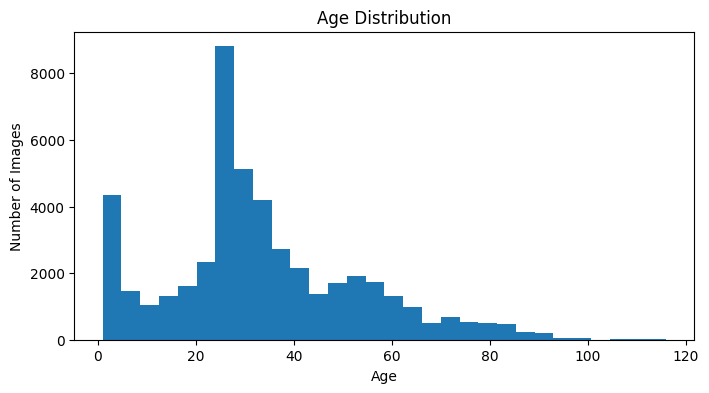

In [11]:
print("Gender distribution:")
print(df["gender"].value_counts())

plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")
plt.show()


In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["gender"]
)

print("Training samples:", train_df.shape)
print("Validation samples:", val_df.shape)


Training samples: (37932, 3)
Validation samples: (9484, 3)


In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image_and_labels(image_path, age, gender):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    labels = {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32)
    }

    return image, labels


def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, ages, genders))
    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

print("TensorFlow datasets created successfully.")


TensorFlow datasets created successfully.


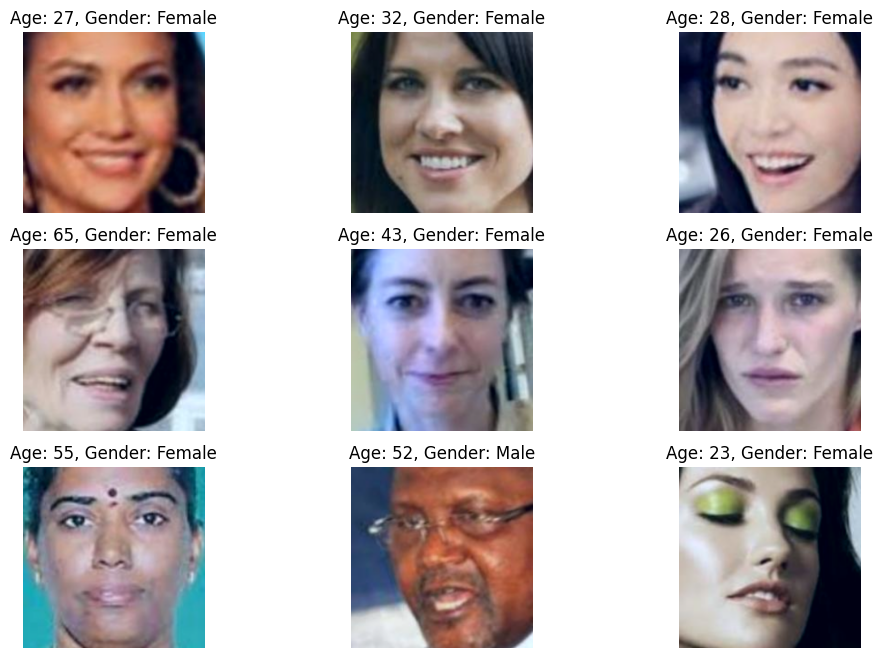

In [15]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(9):
        img = images[i].numpy()
        # Reverse ResNet preprocessing approximately for display
        img = img[..., ::-1]
        img = img + np.array([103.939, 116.779, 123.68])
        img = np.clip(img, 0, 255).astype("uint8")

        age = int(labels["age"][i].numpy())
        gender = int(labels["gender"][i].numpy())
        gender_name = "Female" if gender == 1 else "Male"

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Age: {age}, Gender: {gender_name}")
        plt.axis("off")
    plt.show()

In [17]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

age_output = layers.Dense(1, activation="linear", name="age")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

model = Model(inputs=inputs, outputs={"age": age_output, "gender": gender_output})

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,768,642 (94.48 MB)

 Trainable params: 1,180,930 (4.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0
    }
)

In [24]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet50_age_gender_model.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 186s 141ms/step - age_loss: 10.3631 - age_mae: 10.3621 - gender_accuracy: 0.8135 - gender_loss: 0.4309 - loss: 12.5176 - val_age_loss: 7.6863 - val_age_mae: 7.6838 - val_gender_accuracy: 0.8741 - val_gender_loss: 0.2877 - val_loss: 9.1222 - learning_rate: 1.0000e-04
Epoch 2/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 153s 127ms/step - age_loss: 7.9880 - age_mae: 7.9890 - gender_accuracy: 0.8621 - gender_loss: 0.3214 - loss: 9.5958 - val_age_loss: 7.3027 - val_age_mae: 7.2987 - val_gender_accuracy: 0.8856 - val_gender_loss: 0.2675 - val_loss: 8.6363 - learning_rate: 1.0000e-04
Epoch 3/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 166s 138ms/step - age_loss: 7.5540 - age_mae: 7.5529 - gender_accuracy: 0.8806 - gender_loss: 0.2841 - loss: 8.9734 - val_age_loss: 6.9757 - val_age_mae: 6.9719 - val_gender_accuracy: 0.8892 - val_gender_loss: 0.2529 - val_loss: 8.2368 - learning_rate: 1.0000e-04
Epoch 4/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 152s 126ms/step - age_loss: 7.2950 - 

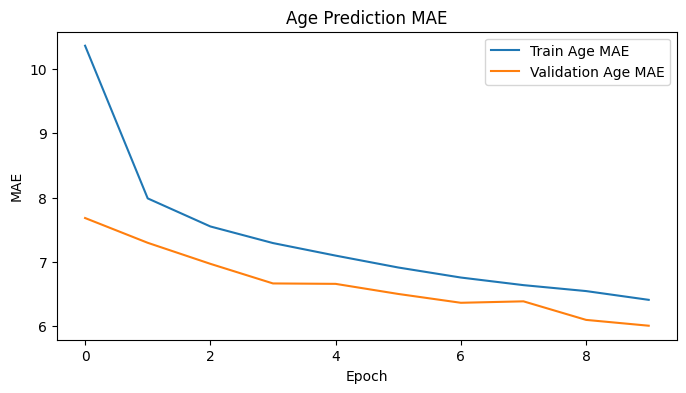

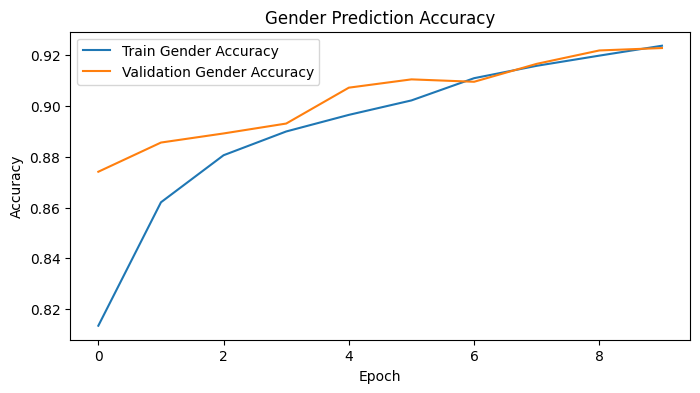

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["age_mae"], label="Train Age MAE")
plt.plot(history.history["val_age_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["gender_accuracy"], label="Train Gender Accuracy")
plt.plot(history.history["val_gender_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
base_model.trainable = True

# Freeze earlier layers and fine-tune only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"]
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0
    }
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 233s 178ms/step - age_loss: 7.2139 - age_mae: 7.2135 - gender_accuracy: 0.8924 - gender_loss: 0.2704 - loss: 8.5650 - val_age_loss: 5.7432 - val_age_mae: 5.7388 - val_gender_accuracy: 0.9290 - val_gender_loss: 0.1829 - val_loss: 6.6535 - learning_rate: 1.0000e-05
Epoch 2/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 199s 165ms/step - age_loss: 5.6046 - age_mae: 5.6052 - gender_accuracy: 0.9376 - gender_loss: 0.1595 - loss: 6.4029 - val_age_loss: 4.7993 - val_age_mae: 4.7936 - val_gender_accuracy: 0.9468 - val_gender_loss: 0.1435 - val_loss: 5.5112 - learning_rate: 1.0000e-05
Epoch 3/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 213s 175ms/step - age_loss: 4.8347 - age_mae: 4.8353 - gender_accuracy: 0.9573 - gender_loss: 0.1160 - loss: 5.4154 - val_age_loss: 4.5618 - val_age_mae: 4.5537 - val_gender_accuracy: 0.9604 - val_gender_loss: 0.1180 - val_loss: 5.1445 - learning_rate: 1.0000e-05
Epoch 4/5
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 199s 166ms/step - age_loss: 4.3357 - age_mae

In [28]:
results = model.evaluate(val_ds)
print("Evaluation Results:", results)


297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - age_loss: 3.6517 - age_mae: 3.6438 - gender_accuracy: 0.9730 - gender_loss: 0.0875 - loss: 4.0823
Evaluation Results: [4.0822529792785645, 3.651672601699829, 0.08752328157424927, 3.643831968307495, 0.9730071425437927]


In [36]:

'''
def predict_age_gender(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    age = prediction["age"][0][0]
    gender_prob = prediction["gender"][0][0]
    gender = "Female" if gender_prob >= 0.5 else "Male"

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted Age: {age:.1f}, Gender: {gender}")
    plt.show()

    print(f"Predicted Age: {age:.1f}")
    print(f"Predicted Gender: {gender}")
    print(f"Gender Probability Female: {gender_prob:.3f}")


# Example:
# predict_age_gender('/content/sample_face.jpg')
'''
def predict_age_gender(input_image):
    if input_image is None:
        return "No image provided", None

    # Preprocess image to match training parameters
    img_array = tf.image.resize(input_image, [IMG_SIZE, IMG_SIZE])
    img_array = tf.expand_dims(img_array, axis=0) # Shape becomes (1, 224, 224, 3)
    img_array = preprocess_input(img_array)

    # Run predictions
    preds = model.predict(img_array)

    # --- PROACTIVE BUG CHECK ---
    # Print shapes to terminal console to verify which output is which
    print("DEBUG - Raw Model Output:", preds)

    # Safe unpacking based on your Keras architecture
    if isinstance(preds, dict):
        age_pred = preds.get('age_output')
        gender_pred = preds.get('gender_output')
    else:
        # If your outputs are swapped in memory, swap these array indices
        age_pred = preds[0]
        gender_pred = preds[1]

    # Safely convert extracted predictions into scalar float numbers
    try:
        age_val = float(np.asarray(age_pred).flatten()[0])
        gender_val = float(np.asarray(gender_pred).flatten()[0])
    except Exception as e:
        return f"Error unpacking values: {e}. Check console log.", None

    # Format outputs
    predicted_age = int(round(age_val))

    # Assuming 0 = Male, 1 = Female based on UTKFace convention
    female_probability = gender_val
    male_probability = 1.0 - female_probability

    gender_results = {
        "Male": male_probability,
        "Female": female_probability
    }

    age_text = f"Estimated Age: {predicted_age} years old"

    return age_text, gender_results


In [37]:
model.save("resnet50_age_gender_final_model.keras")
print("Model saved successfully.")


Model saved successfully.


In [38]:
loaded_model = tf.keras.models.load_model("resnet50_age_gender_final_model.keras")
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

# 1. LOAD YOUR TRAINED MODEL
# Make sure this matches the path where you saved your model weights/file
try:
    # If you saved the model object directly
    # model = tf.keras.models.load_model('Age_Gender_Net.h5')
    print("Model loaded successfully!")
except Exception as e:
    print("Please ensure your model file exists and path is correct. Using current 'model' instance from notebook memory.")

IMG_SIZE = 224

# 2. DEFINE THE INFERENCE FUNCTION
def predict_age_gender(input_image):
    if input_image is None:
        return "No image provided", None

    # Preprocess image to match training parameters
    img_array = tf.image.resize(input_image, [IMG_SIZE, IMG_SIZE])
    img_array = tf.expand_dims(img_array, axis=0) # Add batch dimension -> (1, 224, 224, 3)
    img_array = preprocess_input(img_array) # Scale pixels matching ResNet50 framework

    # Run predictions
    # Model returns a list: [age_prediction, gender_prediction]
    age_pred, gender_pred = model.predict(img_array)

    # Process outputs
    predicted_age = int(np.round(age_pred[0][0]))

    # Assuming 0 = Male, 1 = Female based on UTKFace convention
    female_probability = float(gender_pred[0][0])
    male_probability = 1.0 - female_probability

    gender_results = {
        "Male": male_probability,
        "Female": female_probability
    }

    age_text = f"Estimated Age: {predicted_age} years old"

    return age_text, gender_results

# 3. CONSTRUCT GRADIO INTERFACE STRUCTURE
demo = gr.Interface(
    fn=predict_age_gender,
    inputs=gr.Image(label="Upload or Snap a Face Profile Picture", type="numpy"),
    outputs=[
        gr.Textbox(label="Age Profile Regression Result"),
        gr.Label(label="Gender Target Distribution", num_top_classes=2)
    ],
    title="Demographic Profile AI: Age & Gender Predictor",
    description="Upload a clear face portrait image. The pre-trained ResNet50 Multi-Output Transfer Learning pipeline will estimate the subject's age and determine binary gender parameters.",
    theme="soft"
)

# 4. LAUNCH THE INTERFACE
# 'share=True' creates a public temporary URL if working inside Google Colab
demo.launch(share=True, debug=True)


Model loaded successfully!


/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://10c56c33a1ee405cbc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
